# STEP 1: INSTALL & IMPORT LIBRARIES

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!



# STEP 2: CREATE SYNTHETIC DATASET
We generate synthetic data based on medically accurate ranges
since real angiography datasets are not publicly available

In [ ]:
np.random.seed(42)
n = 300

# --- INPUT FEATURES ---
age            = np.random.randint(30, 80, n)
smoking        = np.random.randint(0, 2, n)       # 0=No, 1=Yes
exercise       = np.random.randint(0, 5, n)        # 0=None to 4=High
diet           = np.random.randint(1, 10, n)        # 1=Poor to 10=Excellent
family_history = np.random.randint(0, 2, n)        # 0=No, 1=Yes

# --- OUTPUT TARGETS (with realistic correlations) ---
stenosis = np.clip(
    30 + (age-30)*0.5 + smoking*20 - exercise*5 - diet*2 + family_history*15 + np.random.normal(0,8,n),
    0, 100).astype(int)

diameter = np.clip(
    4.0 - stenosis*0.025 + np.random.normal(0,0.2,n),
    1.0, 4.0).round(2)

cholesterol = np.clip(
    160 + (age-30)*0.8 + smoking*25 - exercise*8 - diet*3 + family_history*20 + np.random.normal(0,15,n),
    150, 300).astype(int)

bp = np.clip(
    100 + (age-30)*0.6 + smoking*15 - exercise*5 + family_history*10 + np.random.normal(0,10,n),
    90, 180).astype(int)

heart_rate = np.clip(
    80 - exercise*3 + smoking*5 + np.random.normal(0,8,n),
    60, 120).astype(int)

bmi = np.clip(
    25 - exercise*1.2 - diet*0.5 + smoking*1.5 + np.random.normal(0,2,n),
    18, 35).round(1)

risk_score = np.clip(
    (stenosis*0.4 + cholesterol*0.2 + bp*0.2 + bmi*0.2)/4,
    0, 100).round(2)

# Build DataFrame
df = pd.DataFrame({
    'age': age, 'smoking': smoking, 'exercise': exercise,
    'diet': diet, 'family_history': family_history,
    'stenosis': stenosis, 'diameter': diameter,
    'cholesterol': cholesterol, 'bp': bp,
    'heart_rate': heart_rate, 'bmi': bmi, 'risk_score': risk_score
})

print(f'✅ Dataset created: {df.shape[0]} rows × {df.shape[1]} columns')
print('\nFirst 5 rows:')
df.head()

✅ Dataset created: 300 rows × 12 columns

First 5 rows:


,age,smoking,exercise,diet,family_history,stenosis,diameter,cholesterol,bp,heart_rate,bmi,risk_score
0,68,1,4,3,1,47,2.67,192,130,64,20.1,21.80
1,58,1,3,1,1,51,2.57,193,126,69,22.0,22.15
2,44,1,1,5,0,55,2.59,185,105,87,21.6,21.08
3,72,1,0,4,0,57,2.77,186,130,78,22.6,22.63
4,37,1,3,8,1,29,3.16,150,116,93,20.5,17.23


# STEP 3: EXPLORATORY DATA ANALYSIS (EDA)

In [ ]:
print('📊 Dataset Statistics:')
print(df.describe().round(2))

📊 Dataset Statistics:
          age  smoking  exercise    diet  family_history  stenosis  diameter  \
count  300.00   300.00    300.00  300.00          300.00    300.00    300.00   
mean    53.98     0.55      2.04    5.08            0.49     40.81      2.98   
std     14.53     0.50      1.47    2.56            0.50     19.42      0.52   
min     30.00     0.00      0.00    1.00            0.00      0.00      1.57   
25%     41.00     0.00      1.00    3.00            0.00     27.75      2.59   
50%     54.00     1.00      2.00    5.00            0.00     42.00      2.97   
75%     66.00     1.00      3.00    7.00            1.00     55.00      3.34   
max     79.00     1.00      4.00    9.00            1.00     89.00      4.00   

       cholesterol      bp  heart_rate     bmi  risk_score  
count       300.00  300.00      300.00  300.00      300.00  
mean        174.99  117.26       77.00   21.19       19.75  
std          22.20   17.16        9.44    2.64        3.62  
min         1

# CHART 1: Distribution of Input Features

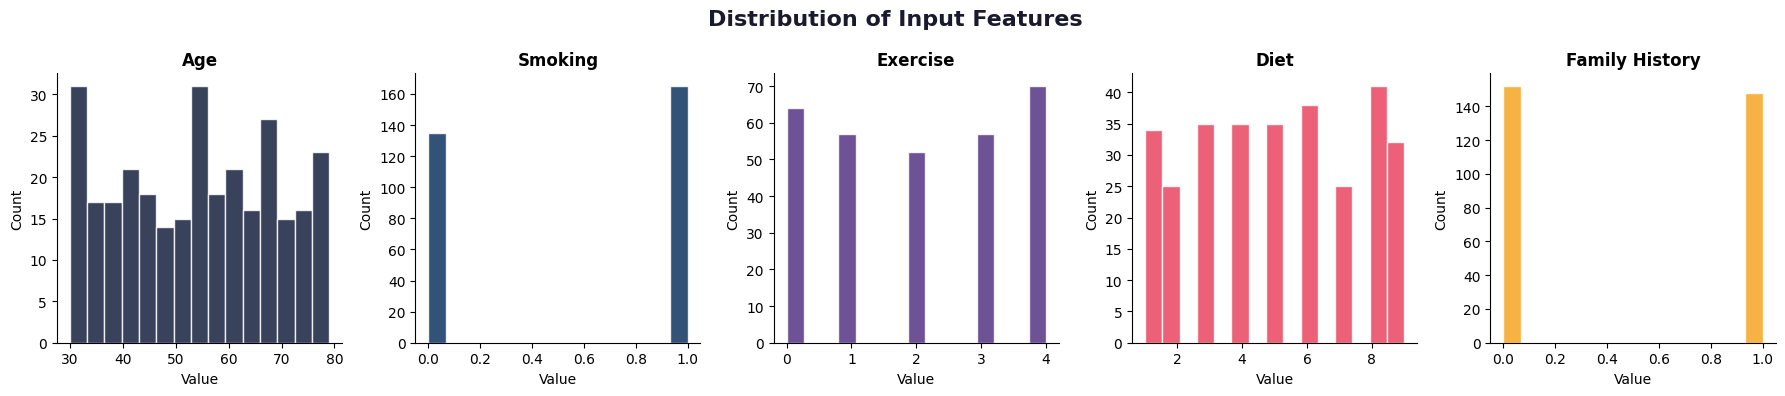

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Distribution of Input Features', fontsize=16, fontweight='bold', color='#1a1a2e')

input_cols = ['age', 'smoking', 'exercise', 'diet', 'family_history']
colors = ['#16213e', '#0f3460', '#533483', '#e94560', '#f5a623']

for ax, col, color in zip(axes, input_cols, colors):
    ax.hist(df[col], bins=15, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# CHART 2: Distribution of Output Targets

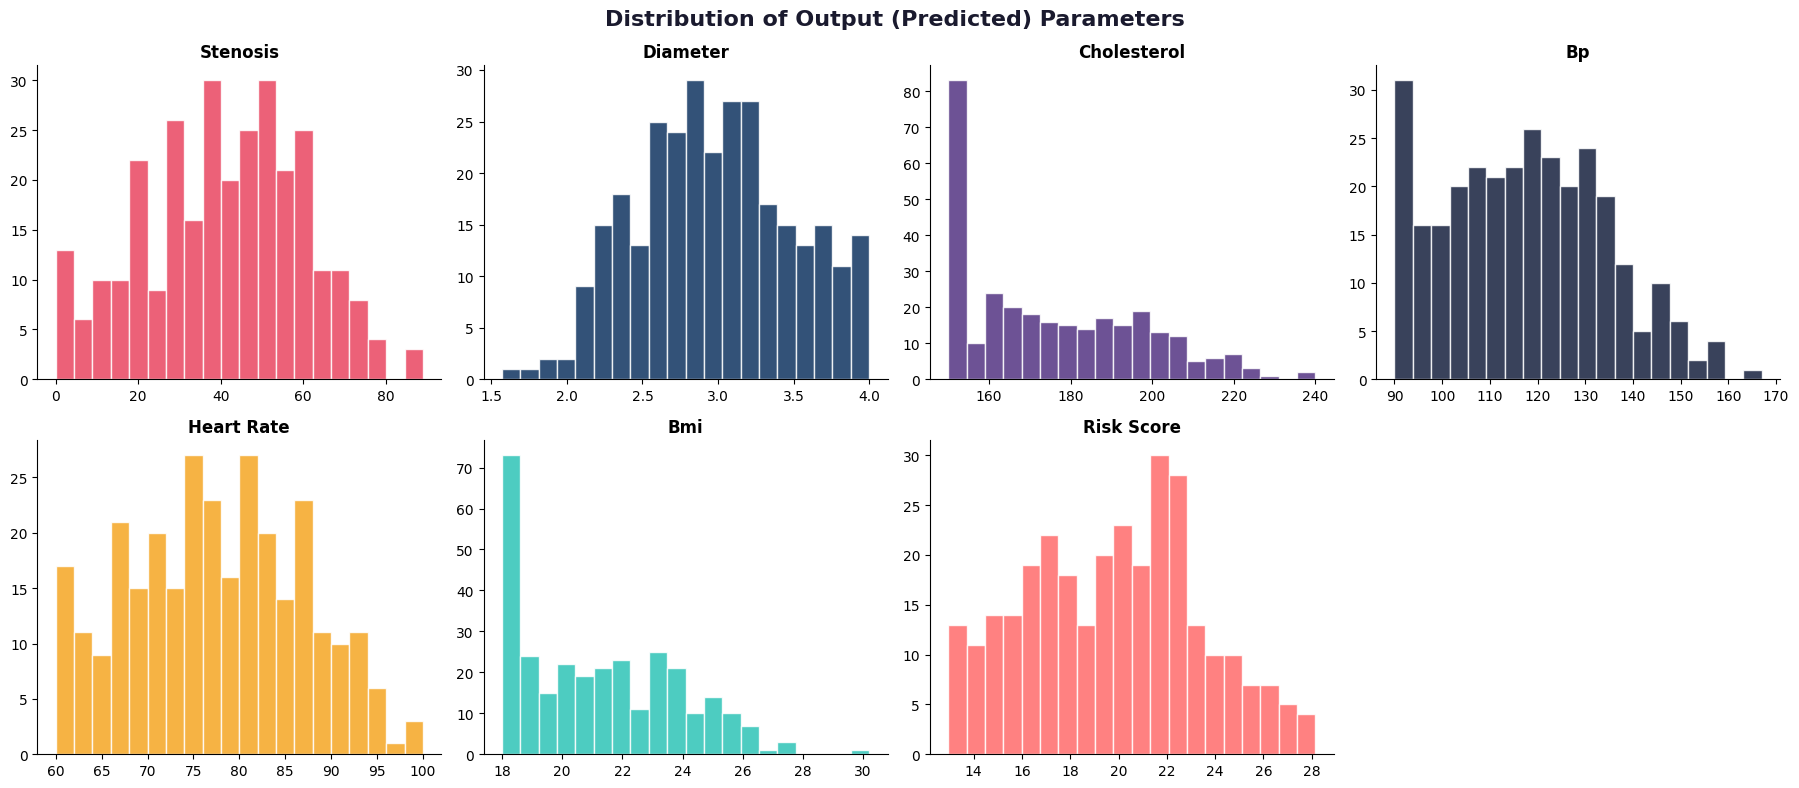

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Distribution of Output (Predicted) Parameters', fontsize=16, fontweight='bold', color='#1a1a2e')
axes = axes.flatten()

output_cols = ['stenosis','diameter','cholesterol','bp','heart_rate','bmi','risk_score']
out_colors = ['#e94560','#0f3460','#533483','#16213e','#f5a623','#2ec4b6','#ff6b6b']

for ax, col, color in zip(axes, output_cols, out_colors):
    ax.hist(df[col], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

# CHART 3: Correlation Heatmap

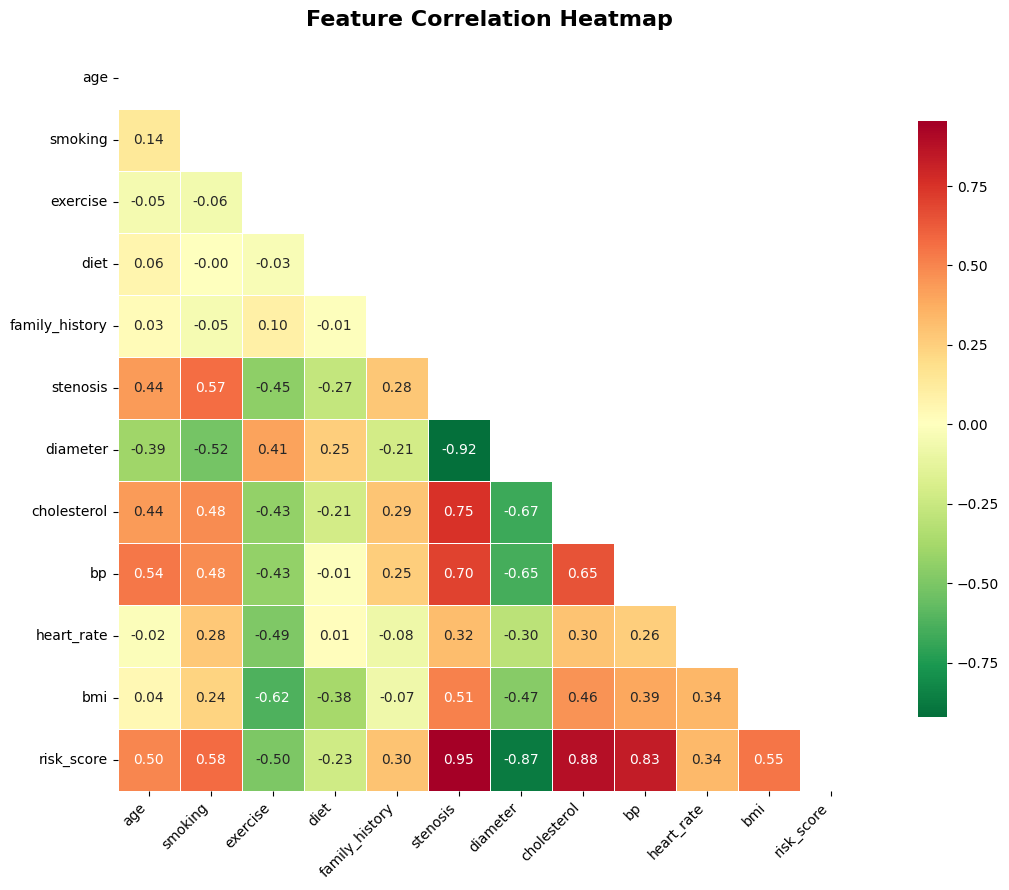


💡 Key insight: Stenosis & Risk Score are highly correlated (as expected medically)


In [ ]:
plt.figure(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print('\n💡 Key insight: Stenosis & Risk Score are highly correlated (as expected medically)')


# STEP 4: PREPARE DATA & TRAIN MODEL


In [ ]:
X = df[['age', 'smoking', 'exercise', 'diet', 'family_history']]
y = df[['stenosis', 'diameter', 'cholesterol', 'bp', 'heart_rate', 'bmi', 'risk_score']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')

# Train Multi-Output Random Forest Regressor
model = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
model.fit(X_train, y_train)

print('\n✅ Model trained successfully!')

Training samples : 240
Testing samples  : 60

✅ Model trained successfully!



# STEP 5: MODEL EVALUATION


In [ ]:
y_pred = model.predict(X_test)

output_names = ['Stenosis', 'Diameter', 'Cholesterol', 'BP', 'Heart Rate', 'BMI', 'Risk Score']

print('📈 Model Performance per Output Parameter:')
print(f'{"Parameter":<14} {"MAE":>8} {"R² Score":>10}')
print('-' * 35)

maes, r2s = [], []
for i, name in enumerate(output_names):
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    r2  = r2_score(y_test.iloc[:, i], y_pred[:, i])
    maes.append(mae)
    r2s.append(r2)
    print(f'{name:<14} {mae:>8.2f} {r2:>10.4f}')

print(f'\nAverage R² Score: {np.mean(r2s):.4f}')

📈 Model Performance per Output Parameter:
Parameter           MAE   R² Score
-----------------------------------
Stenosis           9.98     0.6737
Diameter           0.29     0.5585
Cholesterol        9.37     0.6789
BP                 9.53     0.5171
Heart Rate         7.30     0.1422
BMI                1.51     0.4753
Risk Score         1.32     0.8153

Average R² Score: 0.5516


# CHART 4: R² Score per Output

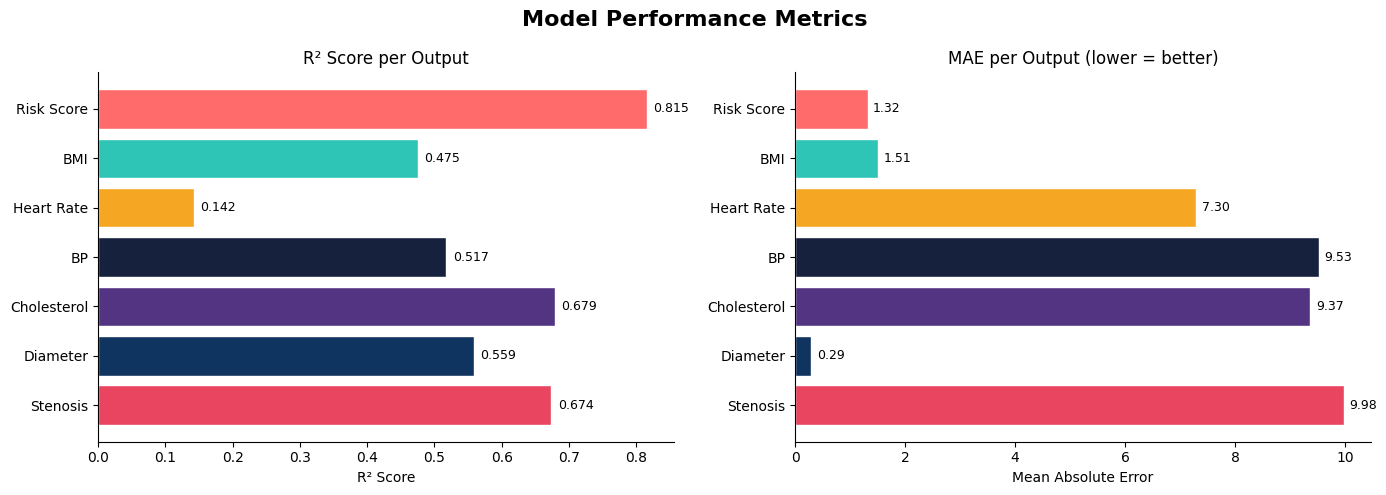

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Performance Metrics', fontsize=16, fontweight='bold')

bar_colors = ['#e94560','#0f3460','#533483','#16213e','#f5a623','#2ec4b6','#ff6b6b']

bars = ax1.barh(output_names, r2s, color=bar_colors, edgecolor='white')
ax1.set_xlabel('R² Score')
ax1.set_title('R² Score per Output')
ax1.axvline(x=0, color='black', linewidth=0.5)
for bar, val in zip(bars, r2s):
    ax1.text(max(val + 0.01, 0.01), bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

bars2 = ax2.barh(output_names, maes, color=bar_colors, edgecolor='white')
ax2.set_xlabel('Mean Absolute Error')
ax2.set_title('MAE per Output (lower = better)')
for bar, val in zip(bars2, maes):
    ax2.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#  CHART 5: Actual vs Predicted for Stenosis & Risk Score

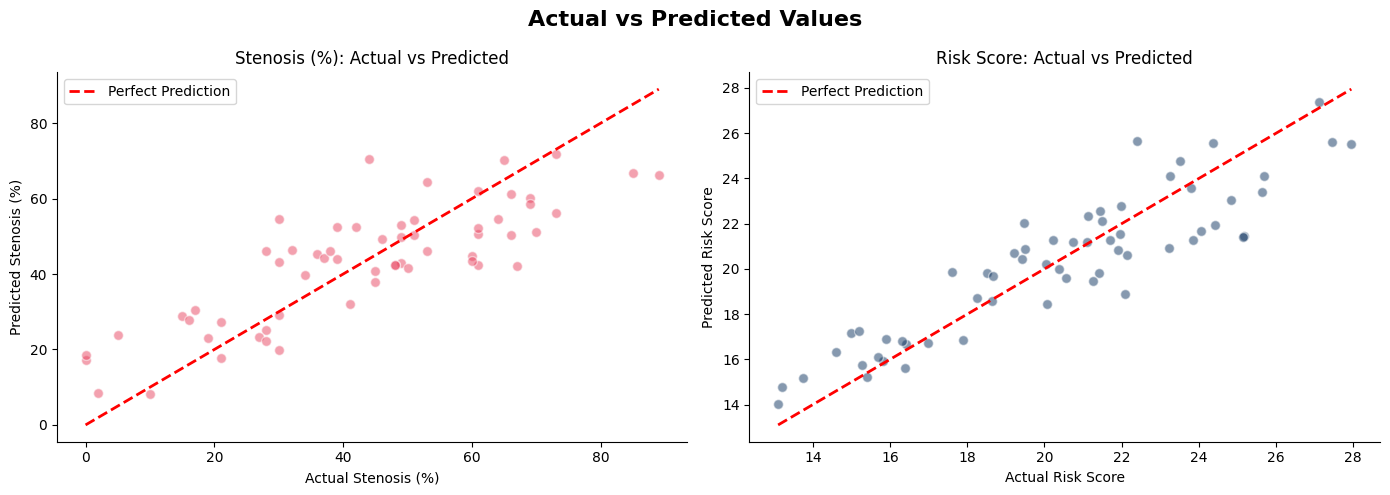

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Actual vs Predicted Values', fontsize=16, fontweight='bold')

for ax, idx, name, color in zip(axes, [0, 6], ['Stenosis (%)', 'Risk Score'], ['#e94560','#0f3460']):
    actual = y_test.iloc[:, idx]
    predicted = y_pred[:, idx]
    ax.scatter(actual, predicted, alpha=0.5, color=color, edgecolors='white', s=50)
    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    ax.set_xlabel(f'Actual {name}')
    ax.set_ylabel(f'Predicted {name}')
    ax.set_title(f'{name}: Actual vs Predicted')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# CHART 6: Feature Importance for Stenosis Prediction

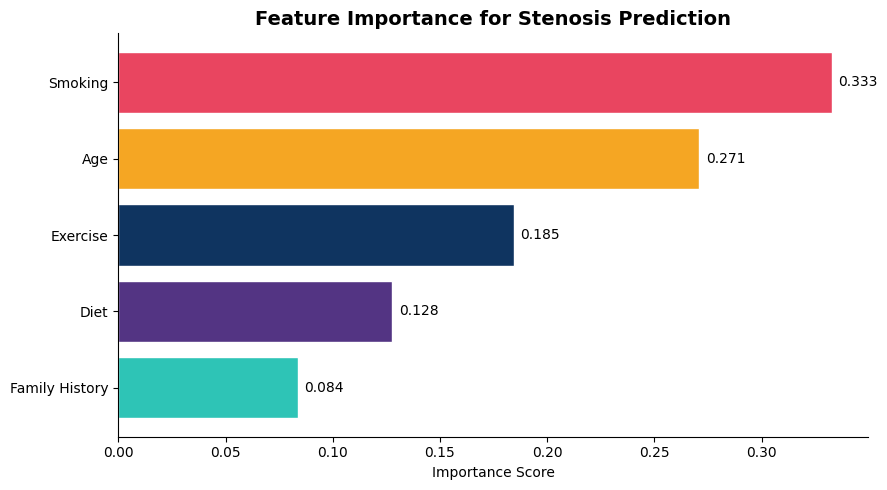

💡 Most important feature: Smoking


In [ ]:
importances = model.estimators_[0].feature_importances_
feat_names  = ['Age', 'Smoking', 'Exercise', 'Diet', 'Family History']

sorted_idx = np.argsort(importances)

plt.figure(figsize=(9, 5))
colors_fi = ['#f5a623','#e94560','#0f3460','#533483','#2ec4b6']
bars = plt.barh([feat_names[i] for i in sorted_idx],
                 importances[sorted_idx], color=[colors_fi[i] for i in sorted_idx], edgecolor='white')
for bar, val in zip(bars, importances[sorted_idx]):
    plt.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)
plt.xlabel('Importance Score')
plt.title('Feature Importance for Stenosis Prediction', fontsize=14, fontweight='bold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('💡 Most important feature:', feat_names[np.argmax(importances)])


# STEP 6: PREDICT FOR A CUSTOM PATIENT
Change these values to test different patients

In [ ]:
print("\n🩺 ENTER PATIENT DETAILS:\n")

age = int(input("Enter Age (30-80): "))

print("Smoking? (0 = No, 1 = Yes)")
smoking = int(input("Enter choice: "))

print("Exercise Level (0-4):")
exercise = int(input("Enter choice: "))

print("Diet (1-10):")
diet = int(input("Enter value: "))

print("Family History? (0 = No, 1 = Yes)")
family_history = int(input("Enter choice: "))

patient = {
    'age': age,
    'smoking': smoking,
    'exercise': exercise,
    'diet': diet,
    'family_history': family_history
}


sample = pd.DataFrame([patient])
result = model.predict(sample)[0]

output_labels = ['Stenosis (%)', 'Artery Diameter (mm)', 'Cholesterol (mg/dL)',
                 'Blood Pressure (mmHg)', 'Heart Rate (bpm)', 'BMI', 'Risk Score (0-100)']

print('\n🩺 PATIENT PROFILE:')
for k, v in patient.items():
    print(f'  {k.replace("_"," ").title():<20}: {v}')

print('\n📊 PREDICTED CARDIOVASCULAR PARAMETERS:')
print('=' * 45)
for label, value in zip(output_labels, result):
    print(f'  {label:<28}: {round(value, 2)}')

risk = result[6]
level = 'HIGH ⚠️' if risk > 50 else ('MODERATE ⚡' if risk > 30 else 'LOW ✅')
print(f'\n🚨 OVERALL RISK LEVEL: {level} (Score: {risk:.1f}/100)')


🩺 ENTER PATIENT DETAILS:

Enter Age (30-80): 59
Smoking? (0 = No, 1 = Yes)
Enter choice: 0
Exercise Level (0-4):
Enter choice: 4
Diet (1-10):
Enter value: 5
Family History? (0 = No, 1 = Yes)
Enter choice: 0

🩺 PATIENT PROFILE:
  Age                 : 59
  Smoking             : 0
  Exercise            : 4
  Diet                : 5
  Family History      : 0

📊 PREDICTED CARDIOVASCULAR PARAMETERS:
  Stenosis (%)                : 12.51
  Artery Diameter (mm)        : 3.6
  Cholesterol (mg/dL)         : 156.89
  Blood Pressure (mmHg)       : 101.76
  Heart Rate (bpm)            : 64.52
  BMI                         : 18.31
  Risk Score (0-100)          : 15.39

🚨 OVERALL RISK LEVEL: LOW ✅ (Score: 15.4/100)


# CHART 7: Patient Risk Radar / Bar Chart
# Normalize output values to 0-100 scale for visualization

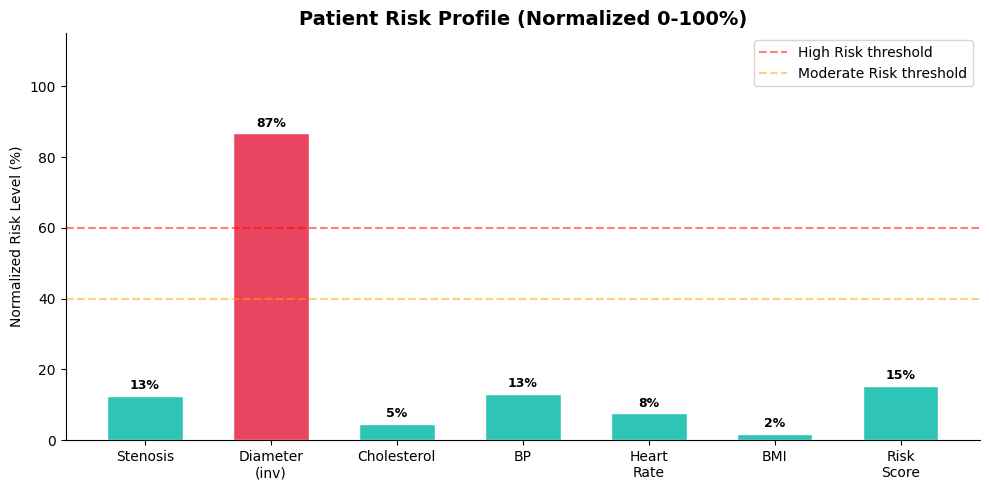

In [ ]:
ranges = {'stenosis':(0,100),'diameter':(1,4),'cholesterol':(150,300),
          'bp':(90,180),'heart_rate':(60,120),'bmi':(18,35),'risk_score':(0,100)}

normalized = []
for val, (lo, hi) in zip(result, ranges.values()):
    normalized.append((val - lo) / (hi - lo) * 100)

short_labels = ['Stenosis','Diameter\n(inv)','Cholesterol','BP','Heart\nRate','BMI','Risk\nScore']

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors2 = ['#e94560' if v > 60 else '#f5a623' if v > 40 else '#2ec4b6' for v in normalized]
bars = ax.bar(short_labels, normalized, color=bar_colors2, edgecolor='white', width=0.6)

ax.axhline(y=60, color='red', linestyle='--', alpha=0.5, label='High Risk threshold')
ax.axhline(y=40, color='orange', linestyle='--', alpha=0.5, label='Moderate Risk threshold')
for bar, val in zip(bars, normalized):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylim(0, 115)
ax.set_ylabel('Normalized Risk Level (%)')
ax.set_title('Patient Risk Profile (Normalized 0-100%)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()